# EDA

Initial look at brand structure, price, reviews, sales, and Amazon's Choice.
Catalog-level plots use `amazon_products_deduped.csv` (one row per product);
the Amazon's Choice plots use `amazon_choice_daily.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BLUE, INK, MUTED = '#2a78d6', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.figsize': (8, 4.5), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': '#e6e5e1', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.titlelocation': 'left', 'axes.titleweight': 'bold',
})

p = pd.read_csv('../data/amazon_products_deduped.csv')
d = pd.read_csv('../data/amazon_choice_daily.csv')
brands = p.groupby('brand').size().sort_values(ascending=False)
print(f'{len(p)} products, {len(brands)} brands')

7946 products, 493 brands


## How many products does each brand have?

In [2]:
print(brands.describe().round(1))
for k in [1, 2, 5, 10, 50]:
    print(f'brands with <= {k:>2} products: {(brands <= k).mean():.0%}')
brands.head(15)

count    493.0
mean      16.1
std       38.5
min        1.0
25%        1.0
50%        4.0
75%       15.0
max      508.0
dtype: float64
brands with <=  1 products: 28%
brands with <=  2 products: 41%
brands with <=  5 products: 56%
brands with <= 10 products: 69%
brands with <= 50 products: 93%


brand
Hp               508
Apple            251
Canon            242
Samsung          224
Lenovo           172
Asus             166
Epson            166
Amazon Basics    163
Brother          154
Logitech         151
Dell             151
Sony             150
Ugreen           145
Garmin           117
Energizer        109
dtype: int64

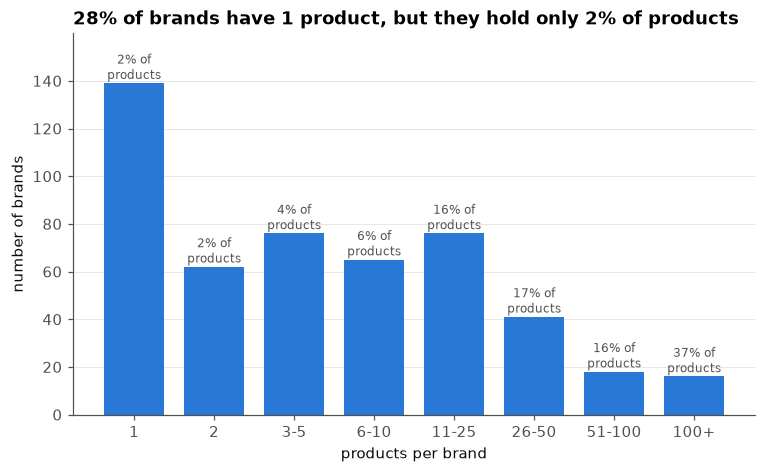

In [3]:
buckets = pd.cut(brands, [0, 1, 2, 5, 10, 25, 50, 100, np.inf],
                 labels=['1', '2', '3-5', '6-10', '11-25', '26-50', '51-100', '100+'])
counts = buckets.value_counts().sort_index()
prods = brands.groupby(buckets, observed=False).sum()
fig, ax = plt.subplots()
ax.bar(counts.index.astype(str), counts.values, color=BLUE, width=0.75)
for i, (nb_, np_) in enumerate(zip(counts, prods)):
    ax.text(i, nb_, f'{np_ / prods.sum():.0%} of\nproducts', ha='center', va='bottom', color=MUTED, fontsize=8)
ax.set_ylim(0, counts.max() * 1.15)
ax.set_xlabel('products per brand')
ax.set_ylabel('number of brands')
ax.set_title(f'{(brands == 1).mean():.0%} of brands have 1 product, but they hold only {prods.iloc[0] / prods.sum():.0%} of products')
ax.grid(axis='x', visible=False);

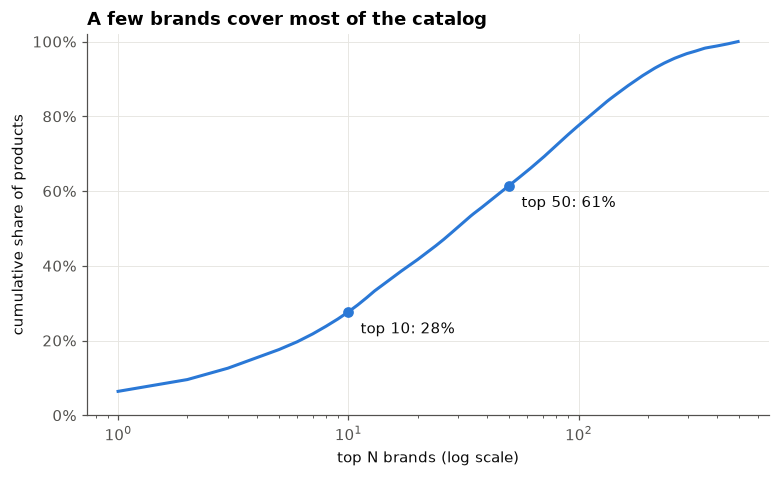

In [4]:
share = brands.cumsum() / brands.sum()
fig, ax = plt.subplots()
ax.plot(np.arange(1, len(share) + 1), share, color=BLUE, lw=2)
ax.set_xscale('log')
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_xlabel('top N brands (log scale)')
ax.set_ylabel('cumulative share of products')
ax.set_title('A few brands cover most of the catalog')
for n in [10, 50]:
    ax.plot(n, share.iloc[n - 1], 'o', color=BLUE, ms=6)
    ax.annotate(f'top {n}: {share.iloc[n - 1]:.0%}', (n, share.iloc[n - 1]), xytext=(8, -14),
                textcoords='offset points', color=INK);

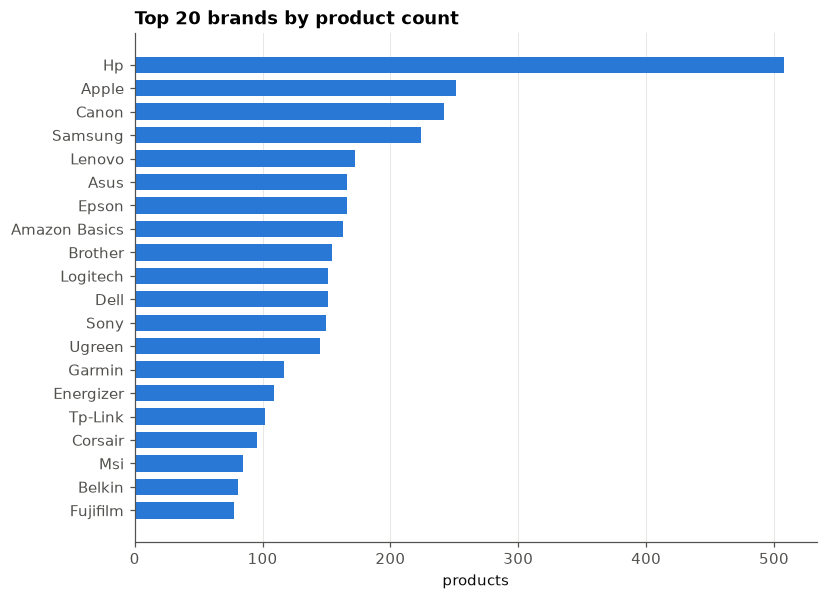

In [5]:
top = brands.head(20)[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=BLUE, height=0.7)
ax.set_xlabel('products')
ax.set_title('Top 20 brands by product count')
ax.grid(axis='y', visible=False);

## Price by category\n\nWhy price tiers have to be within-category: the categories sit at very different price levels.

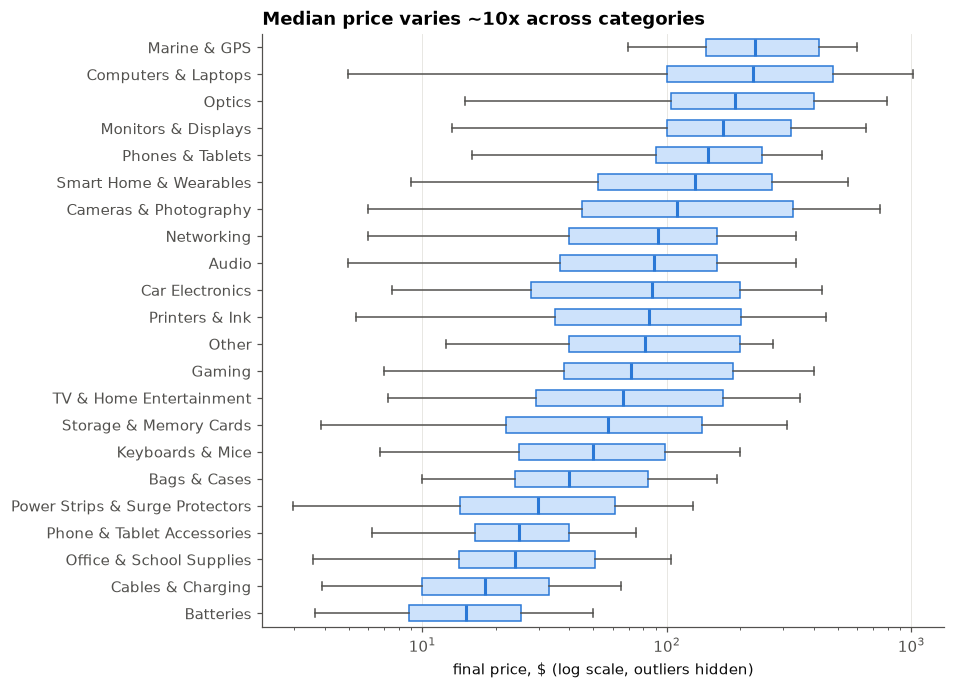

In [6]:
order = p.groupby('category')['final_price'].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 7))
ax.boxplot([p.loc[p.category == c, 'final_price'].dropna() for c in order], orientation="horizontal",
           tick_labels=order, showfliers=False, widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='#cde2fb', edgecolor=BLUE), medianprops=dict(color=BLUE, lw=2),
           whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
ax.set_xscale('log')
ax.set_xlabel('final price, $ (log scale, outliers hidden)')
ax.set_title('Median price varies ~10x across categories')
ax.grid(axis='y', visible=False);

## Reviews vs price\n\nCheap items accumulate more reviews, which is why review count is a volume signal rather than a brand-recognition signal.

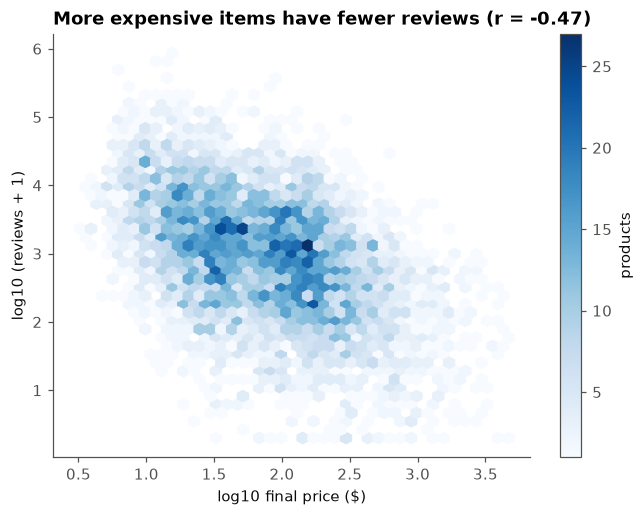

In [7]:
q = p.dropna(subset=['final_price', 'number_of_reviews'])
q = q[q.final_price > 0]
fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(np.log10(q.final_price), np.log10(q.number_of_reviews + 1), gridsize=40, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=ax, label='products')
ax.set_xlabel('log10 final price ($)')
ax.set_ylabel('log10 (reviews + 1)')
r = np.corrcoef(np.log(q.final_price), np.log1p(q.number_of_reviews))[0, 1]
ax.set_title(f'More expensive items have fewer reviews (r = {r:.2f})')
ax.grid(False);

## bought_in_last_month is binned, not continuous\n\nEach value is a lower bound (`300+`), so the model has to treat it as an interval.

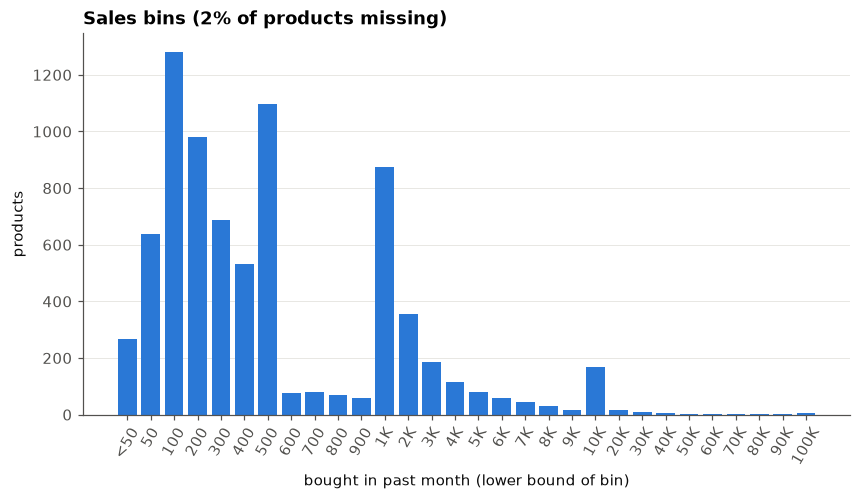

In [8]:
b = p['bought_in_last_month'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(b)), b.values, color=BLUE, width=0.8)
ax.set_xticks(range(len(b)), ['<50' if v == 0 else f'{int(v):,}' if v < 1000 else f'{int(v/1000)}K' for v in b.index], rotation=60)
ax.set_xlabel('bought in past month (lower bound of bin)')
ax.set_ylabel('products')
ax.set_title(f'Sales bins ({p.bought_in_last_month.isna().mean():.0%} of products missing)')
ax.grid(axis='x', visible=False);

## Ratings

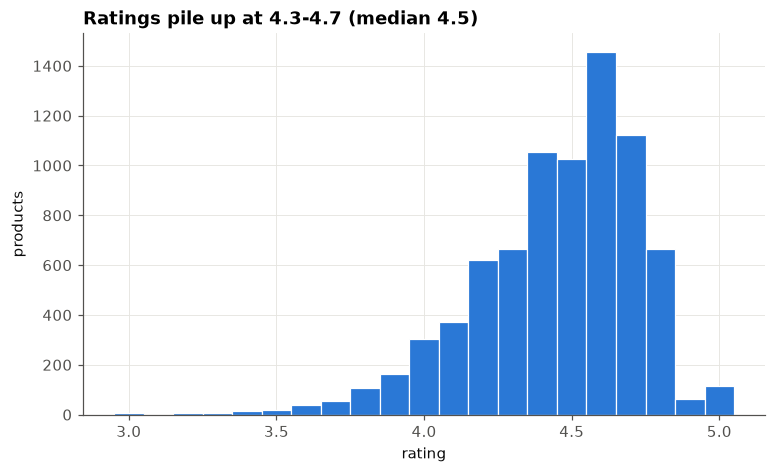

In [9]:
fig, ax = plt.subplots()
ax.hist(p['rating'].dropna(), bins=np.arange(2.95, 5.06, 0.1), color=BLUE, edgecolor='white', linewidth=0.8)
ax.set_xlabel('rating')
ax.set_ylabel('products')
ax.set_title(f'Ratings pile up at 4.3-4.7 (median {p.rating.median()})');

## Amazon's Choice rate by brand: why partial pooling

Each dot is a brand. Small brands scatter wildly (0% or 100%) purely from having
few products; big brands settle near the overall rate. The dashed lines are the
range you'd expect from chance alone if every brand had the same true rate.

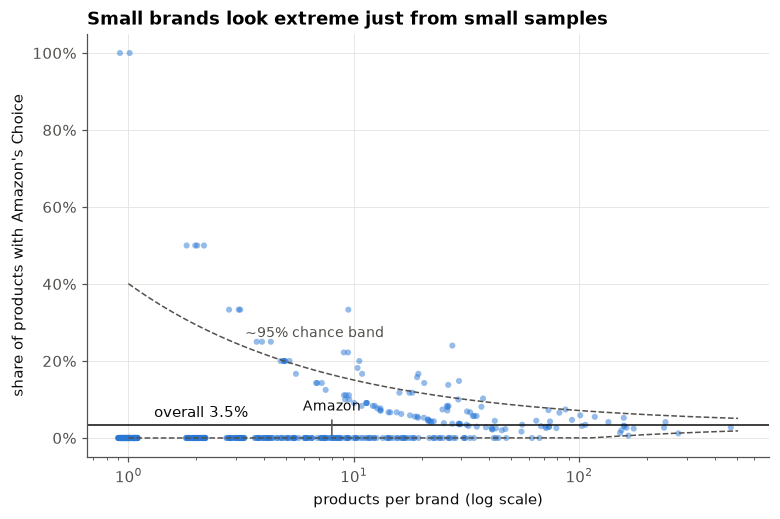

In [10]:
t = d.groupby('Title').agg(brand=('brand', 'first'), ac=('is_amazons_choice', 'any'))
g = t.groupby('brand')['ac'].agg(['mean', 'size'])
base = t['ac'].mean()
n = np.logspace(0, np.log10(g['size'].max()), 200)
se = np.sqrt(base * (1 - base) / n)

fig, ax = plt.subplots(figsize=(8, 5))
jitter = np.random.default_rng(0).uniform(0.9, 1.1, len(g))
ax.scatter(g['size'] * jitter, g['mean'], s=16, color=BLUE, alpha=0.5, edgecolor='none')
ax.plot(n, base + 2 * se, '--', color=MUTED, lw=1)
ax.plot(n, np.clip(base - 2 * se, 0, None), '--', color=MUTED, lw=1)
ax.axhline(base, color=INK, lw=1)
ax.set_xscale('log')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_xlabel('products per brand (log scale)')
ax.set_ylabel("share of products with Amazon's Choice")
ax.set_title("Small brands look extreme just from small samples")
ax.annotate(f'overall {base:.1%}', (1.3, base), xytext=(0, 5), textcoords='offset points', color=INK)
ax.annotate('~95% chance band', (3, base + 2 * np.sqrt(base * (1 - base) / 3)), xytext=(6, 4), textcoords='offset points', color=MUTED, fontsize=9)
ax.annotate('Amazon', (g.loc['Amazon', 'size'], g.loc['Amazon', 'mean']), xytext=(0, 18), textcoords='offset points',
            color=INK, fontsize=9, ha='center', arrowprops=dict(arrowstyle='-', color=MUTED));

## Amazon's Choice rate by category

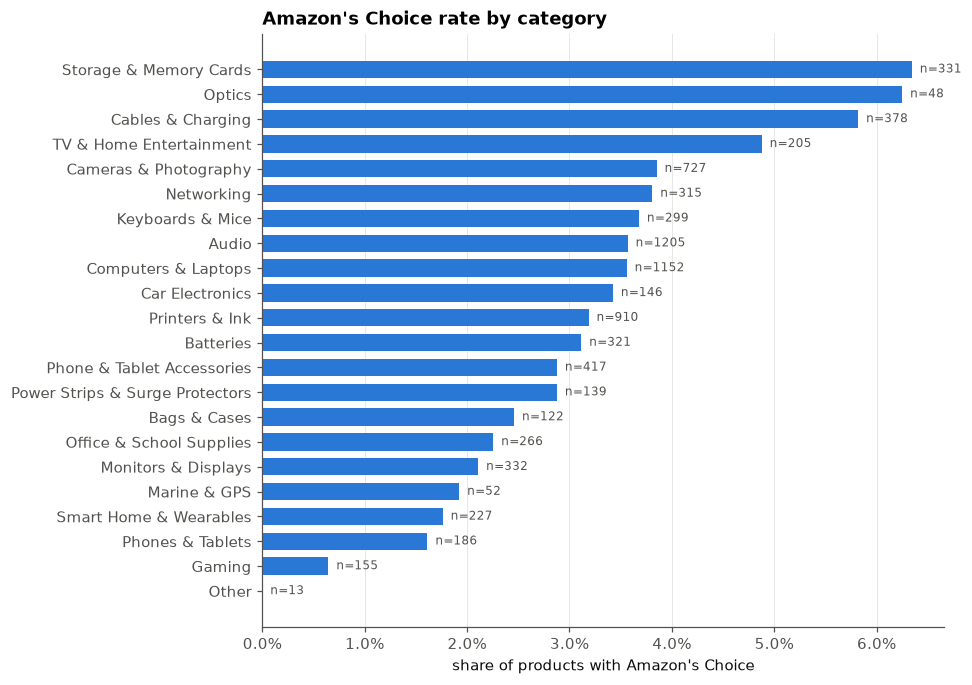

In [11]:
c = t[~t.index.isin(p.Title[p.category == 'Protection Plan'])].join(p.drop_duplicates('Title').set_index('Title')['category']).groupby('category')['ac'].agg(['mean', 'size']).sort_values('mean')
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(c.index, c['mean'], color=BLUE, height=0.7)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_xlabel("share of products with Amazon's Choice")
ax.set_title("Amazon's Choice rate by category")
ax.grid(axis='y', visible=False)
for i, (m, s) in enumerate(zip(c['mean'], c['size'])):
    ax.text(m, i, f'  n={s}', va='center', color=MUTED, fontsize=8);

## Do reviews and price track monthly sales?

Spearman (rank) correlations, because both sales and reviews are heavily
skewed and sales is binned -- rank correlation only asks "does more of one
go with more of the other", which is all a binned lower bound supports.
"Within category" ranks each product inside its own category first, so the
correlation isn't just "batteries are cheap and sell a lot, laptops are
expensive and sell little".

Reviews accumulate over a product's whole life, so they can't *be* last
month's sales. The correlation is still expected: popular products sell
more and so pile up more reviews over time, and more reviews probably help
sell more (social proof). The data can't separate those two directions,
which is why the sales model should be fit with and without review count.

In [12]:
x = p.dropna(subset=['bought_in_last_month', 'number_of_reviews'])
pairs = [('number_of_reviews', 'reviews'), ('final_price', 'price'), ('rating', 'rating')]
rows = []
for col, name in pairs:
    y = x.dropna(subset=[col])
    ranks = y.groupby('category')[[col, 'bought_in_last_month']].rank(pct=True)
    rows.append({'vs bought_in_last_month': name, 'n': len(y),
                 'Spearman': y[col].corr(y['bought_in_last_month'], method='spearman'),
                 'Spearman within category': ranks[col].corr(ranks['bought_in_last_month'])})
pd.DataFrame(rows).set_index('vs bought_in_last_month').round(2)

,n,Spearman,Spearman within category
vs bought_in_last_month,,,
reviews,7717,0.62,0.58
price,5746,-0.56,-0.47
rating,7717,0.22,0.16


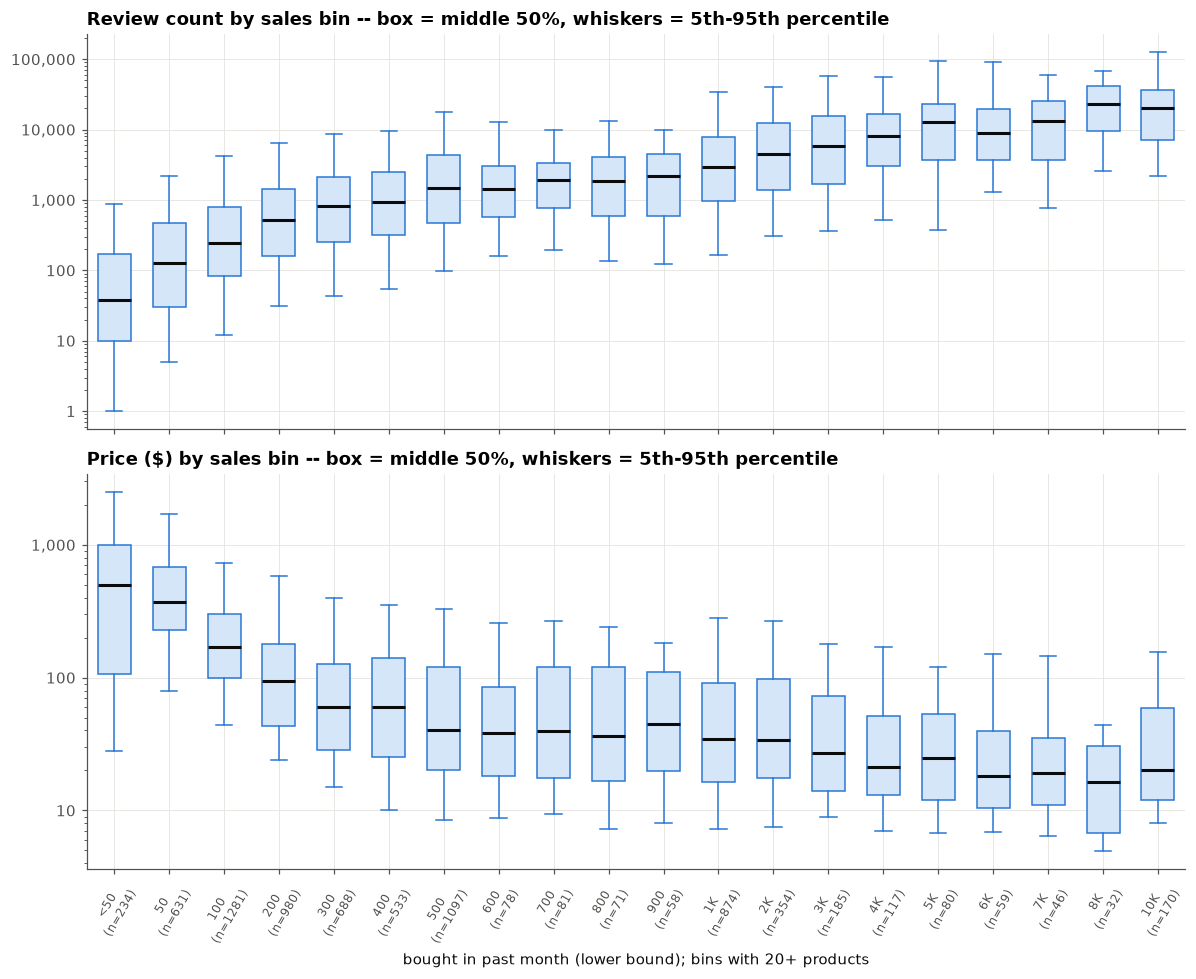

In [13]:
keep = x['bought_in_last_month'].map(x['bought_in_last_month'].value_counts()) >= 20  # drop sparse top bins
vals = sorted(x.loc[keep, 'bought_in_last_month'].unique())
labels = ['<50' if v == 0 else f'{int(v):,}' if v < 1000 else f'{int(v/1000)}K' for v in vals]
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
for ax, col, title in [(axes[0], 'number_of_reviews', 'Review count'), (axes[1], 'final_price', 'Price ($)')]:
    groups = [x.loc[x.bought_in_last_month == v, col].dropna() for v in vals]
    groups = [g[g > 0] for g in groups]  # log scale
    ax.boxplot(groups, whis=(5, 95), showfliers=False, widths=0.6, patch_artist=True,
               boxprops=dict(facecolor='#d6e6f9', edgecolor=BLUE), medianprops=dict(color=INK, lw=2),
               whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.yaxis.set_minor_formatter(plt.matplotlib.ticker.NullFormatter())
    ax.set_title(f'{title} by sales bin -- box = middle 50%, whiskers = 5th-95th percentile')
axes[1].set_xticks(range(1, len(vals) + 1), [f'{l}\n(n={int((x.bought_in_last_month == v).sum())})' for l, v in zip(labels, vals)],
                   rotation=60, fontsize=8)
axes[1].set_xlabel('bought in past month (lower bound); bins with 20+ products')
fig.tight_layout();

Reading it: the *middle* of each bin moves a lot -- median reviews go from
about 130 at "50+" to about 20,000 at "10K+", median price from ~$370 to
~$20 -- but the boxes are tall and overlap heavily between neighbouring
bins. That's why the correlation is ~0.6 rather than ~0.9: the trend is
strong, but any single product scatters widely around it (a product with
1,000 reviews could plausibly be in almost any bin from 100+ to 2K+). Price and reviews are also correlated with each other (cheap
things get more reviews), so in a model they'll partly share the credit.

**Missing sales values:** Amazon only shows the badge at 50+ sales a month,
so in-stock products without it are coded `0` (= fewer than 50) in the
cleaning notebook; they have few reviews (median ~50 vs ~1,000 overall),
consistent with that. Out-of-stock products without the badge stay missing.

## Same question, by category

Is the ~0.6 correlation a mix of categories that each behave differently --
e.g. a mid-price "sweet spot" for laptops that sells best, with cheap and
premium models both selling less? Per category: Spearman correlations, then
median (line) and middle 50% (band) of reviews and of price in each sales
group.

In [14]:
x = p.dropna(subset=['bought_in_last_month'])
x = x[x.category != 'Other']  # 13 products
rows = []
for cat, g in x.groupby('category'):
    gp = g.dropna(subset=['final_price'])
    rows.append({'category': cat, 'n': len(g),
                 'reviews vs sales': g.number_of_reviews.corr(g.bought_in_last_month, method='spearman'),
                 'price vs sales': gp.final_price.corr(gp.bought_in_last_month, method='spearman')})
pd.DataFrame(rows).set_index('category').sort_values('reviews vs sales').round(2)

,n,reviews vs sales,price vs sales
category,,,
Bags & Cases,122,0.35,-0.46
Gaming,118,0.40,-0.49
Car Electronics,146,0.47,-0.56
Monitors & Displays,328,0.51,-0.48
Phone & Tablet Accessories,414,0.53,-0.46
Smart Home & Wearables,224,0.53,-0.32
Cables & Charging,375,0.54,-0.59
Keyboards & Mice,299,0.55,-0.42
Audio,1195,0.55,-0.39


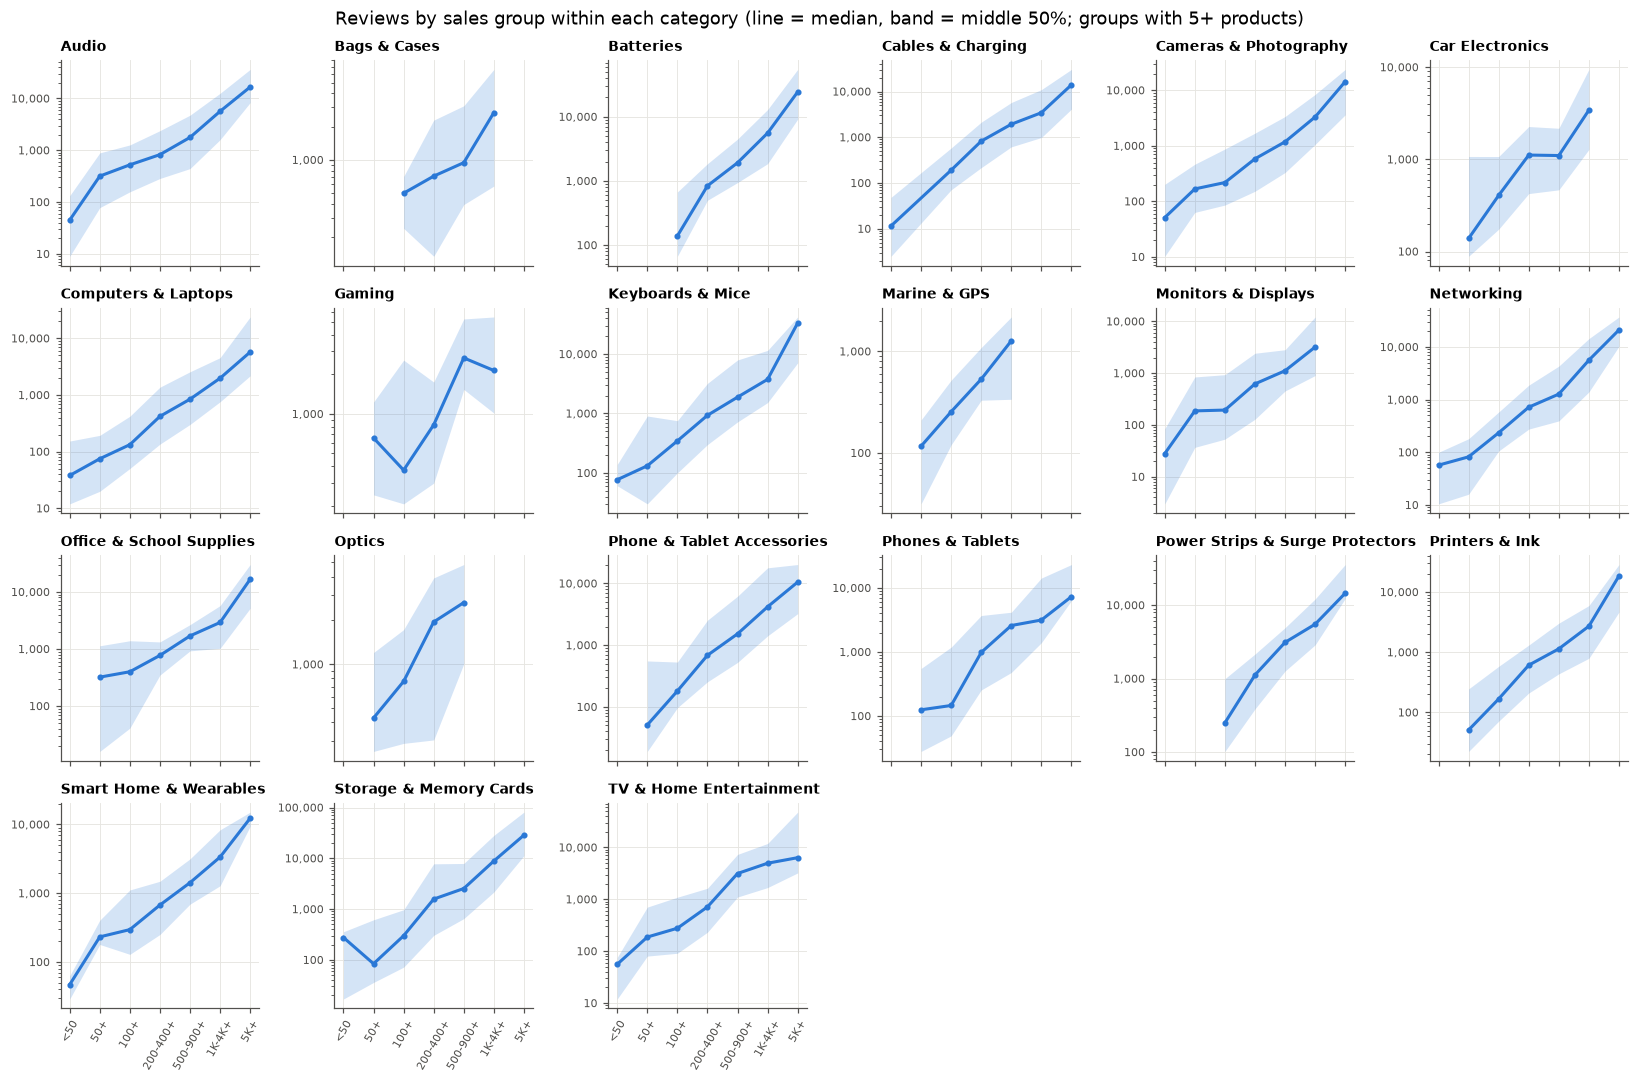

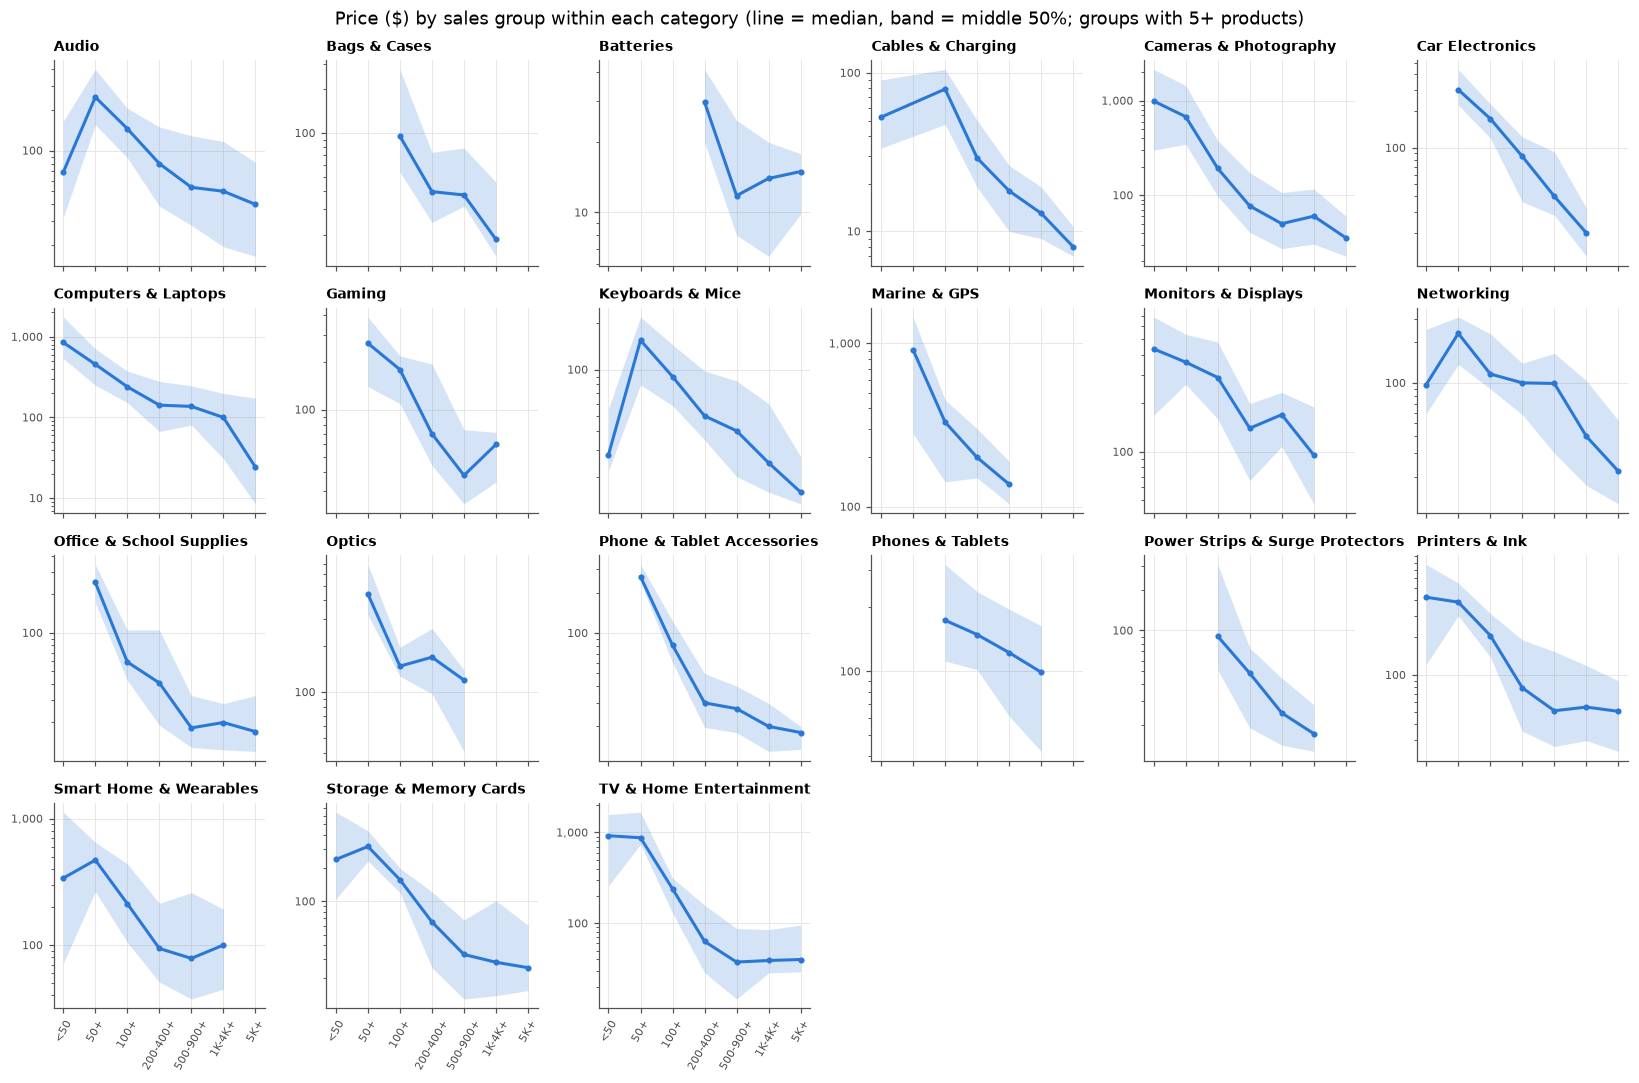

In [15]:
groups = pd.cut(x.bought_in_last_month, [-1, 0, 50, 100, 400, 900, 4000, np.inf],
                labels=['<50', '50+', '100+', '200-400+', '500-900+', '1K-4K+', '5K+'])
cats = sorted(x.category.unique())
for col, ylabel in [('number_of_reviews', 'reviews'), ('final_price', 'price ($)')]:
    fig, axes = plt.subplots(4, 6, figsize=(15, 10), sharex=True)
    for ax, cat in zip(axes.flat, cats):
        g = x[x.category == cat].assign(grp=groups).dropna(subset=[col])
        q = g.groupby('grp', observed=False)[col].quantile([0.25, 0.5, 0.75]).unstack()
        q = q[g.groupby('grp', observed=False).size() >= 5]  # skip groups with <5 products
        pos = [list(groups.cat.categories).index(i) for i in q.index]
        ax.fill_between(pos, q[0.25], q[0.75], color=BLUE, alpha=0.2, lw=0)
        ax.plot(pos, q[0.5], color=BLUE, lw=2, marker='o', ms=3)
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
        ax.yaxis.set_minor_formatter(plt.matplotlib.ticker.NullFormatter())
        ax.set_title(cat, fontsize=9)
        ax.tick_params(labelsize=7)
    for ax in axes.flat[len(cats):]:
        ax.set_visible(False)
    for ax in axes[-1]:
        ax.set_xticks(range(7), groups.cat.categories, rotation=60)
    fig.suptitle(f'{ylabel.capitalize()} by sales group within each category (line = median, band = middle 50%; groups with 5+ products)')
    fig.tight_layout()

Reading it: the pattern is the same in nearly every category -- more
reviews and lower prices go with more sales -- so the overall correlation
isn't a blend of opposite-behaving categories. There's no mid-price peak:
within each category, the cheapest fifth of products has the highest median
sales (a check on laptops alone, ~160 with price and sales, gives the same:
median sales ~200 under $300, ~75 at $500-1,000). The ~0.6 comes from wide
spread around a steady trend, not from a hump. Mild exceptions: Batteries,
Printers & Ink and TV peak in the middle price fifth (pack sizes and
ink-vs-printer mixes within those categories).

## Where do Amazon's Choice products sit on the price / sales curve?

Is the badge concentrated on cheap best-sellers? Badge = seen with the badge
on any day (280 products, 3.5%). Price, reviews and sales are ranked
*within category* and cut into fifths, so "cheapest fifth" means cheap for
its category. Error bars are ±1 standard error.

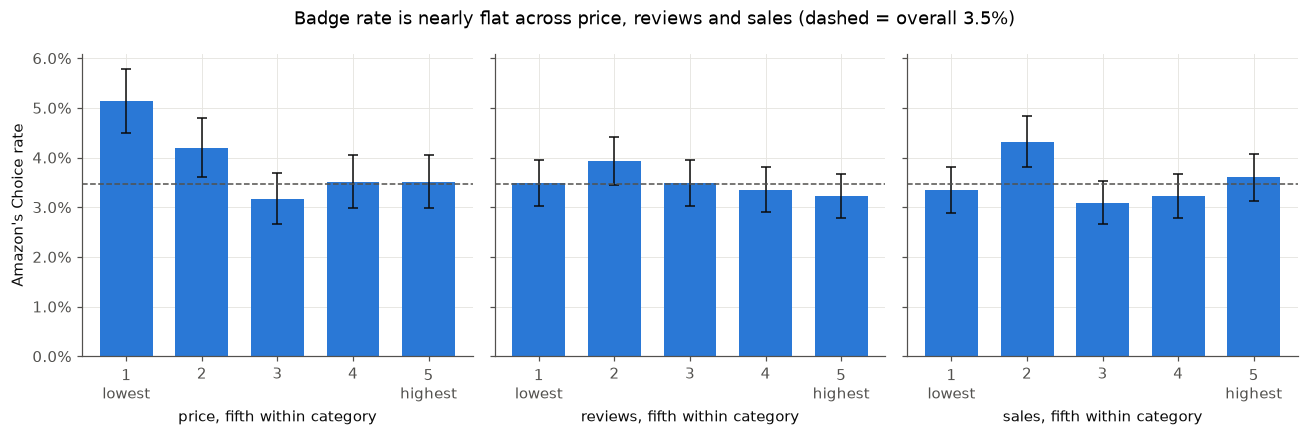

In [16]:
dly = pd.read_csv('../data/amazon_choice_daily.csv')
q = p.assign(badge=p.Title.map(dly.groupby('Title').is_amazons_choice.max()).fillna(False).astype(bool))
panels = [('final_price', 'price'), ('number_of_reviews', 'reviews'), ('bought_in_last_month', 'sales')]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (col, name) in zip(axes, panels):
    fifth = pd.qcut(q.groupby('category')[col].rank(pct=True, method='first'), 5, labels=['1\nlowest', '2', '3', '4', '5\nhighest'])
    r = q.groupby(fifth, observed=True).badge.agg(['mean', 'size'])
    se = np.sqrt(r['mean'] * (1 - r['mean']) / r['size'])
    ax.bar(range(5), r['mean'], color=BLUE, width=0.7)
    ax.errorbar(range(5), r['mean'], yerr=se, fmt='none', ecolor=INK, capsize=3, lw=1)
    ax.axhline(q.badge.mean(), color=MUTED, ls='--', lw=1)
    ax.set_xticks(range(5), r.index)
    ax.set_xlabel(f'{name}, fifth within category')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[0].set_ylabel("Amazon's Choice rate")
fig.suptitle("Badge rate is nearly flat across price, reviews and sales (dashed = overall 3.5%)")
fig.tight_layout()

In [17]:
pd.concat({
    'rating': q.groupby(pd.cut(q.rating, [0, 4, 4.3, 4.5, 4.7, 5]), observed=True).badge.agg(['mean', 'size']),
    'sponsored': q.groupby('is_sponsored').badge.agg(['mean', 'size']),
    'in stock': q.groupby('in_stock').badge.agg(['mean', 'size']),
}).rename(columns={'mean': 'badge rate', 'size': 'products'}).round(3)

badge rate  products
rating    (0.0, 4.0]       0.003       732
          (4.0, 4.3]       0.038      1657
          (4.3, 4.5]       0.032      2084
          (4.5, 4.7]       0.042      2580
          (4.7, 5.0]       0.043       842
sponsored False            0.030      7621
          True             0.148       325
in stock  False            0.023      2565
          True             0.041      5381

Reading it:

- **The badge is not reserved for cheap best-sellers.** Across fifths of
  price, reviews and sales (within category) the badge rate stays between
  ~3% and ~5%. The only tilt is toward the *cheapest* fifth (5.3% vs ~3.5%
  elsewhere, roughly 2-3 standard errors). Badged products sit at the
  median of their category on price, reviews and sales.
- **What does line up with the badge:** rating (products rated 4.0 or
  below almost never get it, 0.3%), **sponsorship (~15% of sponsored
  products vs 3%)** and being in stock (4.1% vs 2.3%).
- On real Amazon the badge is described as going to well-rated,
  well-priced, available products that sell well; the missing link to sales
  and reviews here may be a sign of the data being synthetic -- worth
  keeping in mind when interpreting the model. The sponsored link is the
  most interesting lead: it's a large difference, and it's exactly the kind
  of "does Amazon favour what it profits from" question the model is for.

## Near-duplicate listings (`product_family`)

Many titles are variants of one product (toner colours, capacity or colour
options, re-listings). The cleaning notebook groups them into
`product_family` (same brand, near-identical title). They stay as separate
products -- they're separate listings with their own sales and badge -- but
a model should know they're related.

In [18]:
fam = p.groupby('product_family').agg(size=('Title', 'size'), brand=('brand', 'first'), example=('Title', 'first'))
print(f"{(fam['size'] > 1).sum()} families with 2+ listings, covering {fam.loc[fam['size'] > 1, 'size'].sum()} "
      f"of {len(p)} products ({fam.loc[fam['size'] > 1, 'size'].sum() / len(p):.0%})")
fam.sort_values('size', ascending=False).head(10)

594 families with 2+ listings, covering 1606 of 7946 products (20%)


,size,brand,example
product_family,,,
48,19,Epson,EPSON 822 DURABrite Ultra Ink High Capacity Bl...
542,17,Hp,HP 202A Black Toner Cartridge | Works with HP ...
680,12,Epson,EPSON 212 Claria Ink High Capacity Black & Sta...
1516,11,Hp,HP 508A Black Toner Cartridge | Works with HP ...
773,10,G.Skill,G.SKILL Trident Z5 Neo RGB Series (AMD Expo) D...
399,10,Lenovo,"Lenovo IdeaPad 1 Student Laptop, 15.6"" FHD Dis..."
1419,10,Epson,EPSON 220 DURABrite Ultra Ink Standard Capacit...
564,10,Apple,"Apple Watch Series 7 (GPS, 45mm) Midnight Alum..."
164,10,Corsair,CORSAIR VENGEANCE LPX DDR4 RAM 32GB (2x16GB) 3...


## How often was each product scraped?

The raw data captured some listings hundreds of times. Is that Amazon
showing some products more (a recommendation signal), or an artifact of how
the scraper ran? Counts are listing observations per distinct product in the
cleaned file.

scraped <=  1 times: 87.5% of products
scraped <=  2 times: 94.5% of products
scraped <=  5 times: 95.5% of products
scraped <= 20 times: 96.4% of products
top 1% of products = 37% of all rows


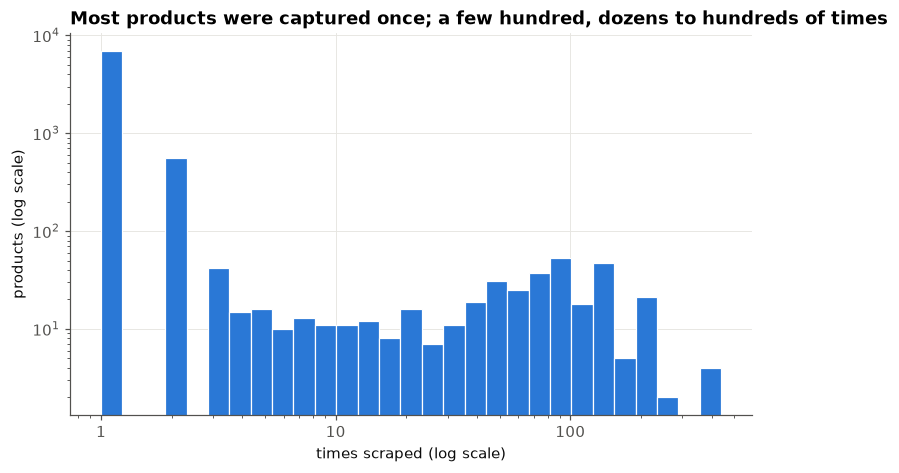

In [19]:
obs = pd.read_csv('../data/amazon_sales_data_cleaned.csv', parse_dates=['collected_at'])
g = obs.groupby('Title').agg(scrapes=('Title', 'size'), sponsored=('is_sponsored', 'mean'),
                             badge=('is_amazons_choice', 'mean'),
                             span_hours=('collected_at', lambda s: (s.max() - s.min()).total_seconds() / 3600))
g = g.join(p.set_index('Title')[['category', 'bought_in_last_month', 'number_of_reviews', 'final_price']])
for k in [1, 2, 5, 20]:
    print(f'scraped <= {k:>2} times: {(g.scrapes <= k).mean():.1%} of products')
top = g.scrapes.sort_values(ascending=False)
print(f'top 1% of products = {top.head(len(g) // 100).sum() / len(obs):.0%} of all rows')

fig, ax = plt.subplots()
ax.hist(g.scrapes, bins=np.logspace(0, np.log10(g.scrapes.max() + 1), 30), color=BLUE, edgecolor='white', linewidth=0.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_xlabel('times scraped (log scale)'); ax.set_ylabel('products (log scale)')
ax.set_title('Most products were captured once; a few hundred, dozens to hundreds of times');

In [20]:
g['times scraped'] = pd.cut(g.scrapes, [0, 1, 2, 5, 20, np.inf], labels=['1', '2', '3-5', '6-20', '21+'])
g.groupby('times scraped', observed=True).agg(
    products=('scrapes', 'size'), share_sponsored=('sponsored', 'mean'), badge_rate=('badge', 'mean'),
    median_hours_first_to_last=('span_hours', 'median'), median_sales=('bought_in_last_month', 'median'),
    median_reviews=('number_of_reviews', 'median'), median_price=('final_price', 'median')).round(2)

,products,share_sponsored,badge_rate,median_hours_first_to_last,median_sales,median_reviews,median_price
times scraped,,,,,,,
1,6953,0.02,0.02,0.00,400.0,992.0,76.94
2,559,0.10,0.02,0.10,100.0,394.0,70.11
3-5,73,0.59,0.04,0.65,100.0,318.0,69.95
6-20,71,0.70,0.05,33.03,200.0,617.0,59.99
21+,290,0.16,0.02,1.02,100.0,293.0,99.99


Reading it:

- **87% of products were captured once**; 293 products (under 4%) were
  captured 21+ times and make up a large share of all rows (the reason the
  cleaning notebook deduplicates to one row per product).
- **The heavy repeats are scraper bursts, not Amazon promoting products.**
  A product captured 21+ times typically got all its captures within about
  an hour, and most of them are *not* sponsored. They also sell *less* than
  average (median 100/month vs 400) and have fewer reviews -- the opposite
  of what "Amazon keeps recommending it" would predict.
- **Products captured 3-20 times are mostly sponsored** (58-70%): ads
  rotating through ad slots across searches. That's a real signal about
  sponsorship, but it's already in `is_sponsored`.
- By category, repeat rates are similar (6-17% of products scraped more
  than once); Optics is highest on average because a few listings were
  captured in bursts.

So scrape count shouldn't be used as a popularity or recommendation
signal -- it mostly reflects when and how the scraper ran.